In [34]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches

In [35]:
#中间矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m, B, a):
    return (m + 4*B/(a**2)) * sz

def h_x(B, a, A):
    return ((-B/(a**2))*sz - (1j/2)*A*sx) 
    
def h_y(B, a, A, Bz,xweizhi):
    return ((-B/(a**2))*sz - (1j/2)*A*sy) * np.exp(-(2*np.pi*1j*a**2)*Bz*xweizhi)

def h_onstie(m, B, a, u):
    return h_k(m, B, a) - u*s0

def t_x(B, a, A):
    return h_x(B, a, A)

def t_y(B, a, A, Bz, xweizhi):
    return h_y(B, a, A, Bz, xweizhi)


def H_onstie(m, B, a, u_set, xshumu, Nd, A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = h_onstie(m, B, a, u_set[i])

        if i < xshumu - 1:
            H[i][i+1] = t_x(B, a, A)

        if i > 0:
            H[i][i-1] = t_x(B, a, A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B, a, A, xshumu, Nd,Bz):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        xweizhi=i
        H[i][i] = t_y(B, a, A, Bz,xweizhi)

    H = np.block(H)
    return H


m = -0.5       # 质量项
A = 1.0        # 费米速度项
B = 0.5      # 二阶动量项
Bz = 0.0  # 磁场
Ex=0

a = 1          # 晶格常数
yshumu = 28
xshumu = 8

uS = 0
uS_set = []
for i in range(xshumu):
    uS_set.append(uS - Ex * 1 * (i - xshumu/2))

uS_set_base = np.array(uS_set)


Nd = 2


H_q=H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)

H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
    H_q_list.append(H_q_i)

T_21 = H_hop(B, a, A, xshumu, Nd,Bz)



In [36]:
## 两边金属线
t = 1
tc = 1 * t
mu = 1
weidu = 2
kuandu = 8  # 电极的横向宽度
Nd = 2        # 2x2 正常态

def H_onsite_1(t,mu ,weidu):
    HX_block = -(mu - 2*weidu*t)*s0 
    return HX_block

def H_hop_1(t):
    # 纯粹的最近邻跳跃
    H_X_right_to_left_hop_block = -t * s0
    return H_X_right_to_left_hop_block

def H_onsite_2(t,mu, weidu, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):
        H[i][i] = H_onsite_1(t,mu, weidu)


        if i < kuandu - 1:
            H[i][i+1] = H_hop_1(t)
        if i > 0:
            H[i][i-1] = H_hop_1(t).conj().T
    
    return np.block(H)

def H_hop_2(t, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):

        H[i][i] = H_hop_1(t)

    return np.block(H)

H_l = H_onsite_2(t,mu, weidu, kuandu)
T_l = H_hop_2(t, kuandu)

H_r = H_onsite_2(t,mu, weidu, kuandu)
T_r = H_hop_2(t, kuandu).conj().T


#整体耦合块
T_c = H_hop_2(tc, kuandu) 

# 左电极耦合矩阵
T_LD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_LD[:, :Nd * kuandu] = T_c.conj().T

# 右电极耦合矩阵
T_RD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_RD[:, :Nd * kuandu] = T_c


In [37]:
def H_onstie_lead_y(m, B, a, mu_set, yshumu_lead, Nd, A, Bz, x_weizhi_edge):
    """构建引线内部的哈密顿量（切片内部沿 y 方向，使用 t_y）"""
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu_lead)] for _ in range(yshumu_lead)]
    for i in range(yshumu_lead):
        H[i][i] = h_onstie(m, B, a, mu_set[i])
        if i < yshumu_lead - 1:
            H[i][i+1] = t_y(B, a, A, Bz, x_weizhi_edge)
        if i > 0:
            H[i][i-1] = t_y(B, a, A, Bz, x_weizhi_edge).conj().T
    return np.block(H)

def T_hop_lead_x(B, a, A, yshumu_lead, Nd):
    """构建引线层与层之间的跳跃矩阵（沿 x 方向，使用 t_x）"""
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu_lead)] for _ in range(yshumu_lead)]
    for i in range(yshumu_lead):
        H[i][i] = t_x(B, a, A)
    return np.block(H)

# =========================================================================
# 你的四条电压探测引线 (Top: 1, 2 | Bottom: 3, 4)
# =========================================================================

# 获取 x 方向向外跳跃的基础矩阵
tx_mat = t_x(B, a, A)

# ----------------- Top Leads (上方引线，位于 x = xshumu - 1) -----------------
top_x_edge = xshumu - 1

# 引线 1 (左上)
yshumu_1 = 2
mu_1_set = np.zeros(yshumu_1)
H_y1 = H_onstie_lead_y(m, B, a, mu_1_set, yshumu_1, Nd, A, Bz, top_x_edge)
T_21_y1 = T_hop_lead_x(B, a, A, yshumu_1, Nd) 

# 引线 2 (右上)
yshumu_2 = 2
mu_2_set = np.zeros(yshumu_2)
H_y2 = H_onstie_lead_y(m, B, a, mu_2_set, yshumu_2, Nd, A, Bz, top_x_edge)
T_21_y2 = T_hop_lead_x(B, a, A, yshumu_2, Nd)

# ----------------- Bottom Leads (下方引线，位于 x = 0) -----------------
bottom_x_edge = 0

# 引线 3 (左下)
yshumu_3 = 2
mu_3_set = np.zeros(yshumu_3)
H_y3 = H_onstie_lead_y(m, B, a, mu_3_set, yshumu_3, Nd, A, Bz, bottom_x_edge)
# 底部引线向 -x 延伸，跳跃矩阵可能需要共轭（视你的规范约定而定，通常与上方相反）
T_21_y3 = T_hop_lead_x(B, a, A, yshumu_3, Nd).conj().T


# 引线 4 (右下)
yshumu_4 = 2
mu_4_set = np.zeros(yshumu_4)
H_y4 = H_onstie_lead_y(m, B, a, mu_4_set, yshumu_4, Nd, A, Bz, bottom_x_edge)
T_21_y4 = T_hop_lead_x(B, a, A, yshumu_4, Nd).conj().T


In [38]:
#function
def gr_L_keni(T_l, A_l, tol=1e-6):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

    
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL


def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, 
          H_y1, T_21_y1, 
          H_y2, T_21_y2, 
          H_y3, T_21_y3, 
          H_y4, T_21_y4, 
          yshumu, E, eta=1e-6):
    """
    通过局部坐标寻址嵌入引线自能的工业级高效 Gr_DD 函数
    彻底抛弃全局大矩阵乘法，速度极快且不占内存
    """
    d_device = H_q_list[0].shape[0]  # Nd * xshumu = 16
    d_lead = H_l.shape[0]            # 左右电极维度 = 16
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # 1. 计算左、右主电极自能 (局部自能)
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    # 2. 计算上、下四根引线的 4x4 表面格林函数
    g_y1 = gr_L_keni(T_21_y1, (E + 1j*eta) * np.eye(H_y1.shape[0]) - H_y1)
    g_y2 = gr_L_keni(T_21_y2, (E + 1j*eta) * np.eye(H_y2.shape[0]) - H_y2)
    g_y3 = gr_L_keni(T_21_y3, (E + 1j*eta) * np.eye(H_y3.shape[0]) - H_y3)
    g_y4 = gr_L_keni(T_21_y4, (E + 1j*eta) * np.eye(H_y4.shape[0]) - H_y4)

    # 3. 建立 6 端全局自能矩阵 (为了完美兼容你后面的展宽和电导计算，直接对角寻址赋值)
    N_total = d_device * yshumu
    Sigma_y1_g = np.zeros((N_total, N_total), dtype=complex)
    Sigma_y2_g = np.zeros((N_total, N_total), dtype=complex)
    Sigma_y3_g = np.zeros((N_total, N_total), dtype=complex)
    Sigma_y4_g = np.zeros((N_total, N_total), dtype=complex)

    # 定义一个内部闭包函数：把 4x4 的引线自能直接摆到 448x448 全局矩阵的正确坑位上
    def embed_lead_sigma(g_y, y_start, x_edge, t_coupling, Sigma_global):
        # g_y 是 4x4, t_coupling 是 2x2 (tx_mat 或 tx_mat.conj().T)
        for i_l in range(2):
            for j_l in range(2):
                g_block = g_y[i_l*Nd : (i_l+1)*Nd, j_l*Nd : (j_l+1)*Nd]
                # 相当于原来的 T_c.conj().T @ g_block @ T_c 局部版
                sigma_block = t_coupling.conj().T @ g_block @ t_coupling
                
                # 计算在 448x448 全局矩阵里的行和列绝对索引
                row_idx = (y_start + i_l) * d_device + x_edge * Nd
                col_idx = (y_start + j_l) * d_device + x_edge * Nd
                Sigma_global[row_idx:row_idx+Nd, col_idx:col_idx+Nd] = sigma_block

    # 获取耦合跳跃矩阵
    tx_mat = t_x(B, a, A)
    
    # 精准寻址嵌入四根引线
    embed_lead_sigma(g_y1, y_start=8,  x_edge=xshumu-1, t_coupling=tx_mat.conj().T, Sigma_global=Sigma_y1_g)
    embed_lead_sigma(g_y2, y_start=18, x_edge=xshumu-1, t_coupling=tx_mat.conj().T, Sigma_global=Sigma_y2_g)
    embed_lead_sigma(g_y3, y_start=8,  x_edge=0,        t_coupling=tx_mat,          Sigma_global=Sigma_y3_g)
    embed_lead_sigma(g_y4, y_start=18, x_edge=0,        t_coupling=tx_mat,          Sigma_global=Sigma_y4_g)

    # 4. 依照分块构建主干 A_DD 
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]
    for i in range(yshumu):
        H_q_i = H_q_list[i]
        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    # 5. 展平大矩阵并扣除四根引线的自能
    A_DD = np.block(A_DD)
    A_DD -= (Sigma_y1_g + Sigma_y2_g + Sigma_y3_g + Sigma_y4_g)
    
    # 最终求逆
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_L, Sigma_R, Sigma_y1_g, Sigma_y2_g, Sigma_y3_g, Sigma_y4_g



In [39]:
G_DD_r, Sigma_L, Sigma_R, Sigma_y1, Sigma_y2, Sigma_y3, Sigma_y4= Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, 
          H_y1, T_21_y1, 
          H_y2, T_21_y2, 
          H_y3, T_21_y3, 
          H_y4, T_21_y4, 
          yshumu, E=0.25, eta=1e-6)

N_total = G_DD_r.shape[0]
d_slice = Sigma_L.shape[0]

Sigma_L_global = np.zeros((N_total, N_total), dtype=complex)
Sigma_R_global = np.zeros((N_total, N_total), dtype=complex)

Sigma_L_global[:d_slice, :d_slice] = Sigma_L
Sigma_R_global[-d_slice:, -d_slice:] = Sigma_R

zhaunkuan_L  = 1j * (Sigma_L_global - Sigma_L_global.conj().T)
zhaunkuan_R  = 1j * (Sigma_R_global - Sigma_R_global.conj().T)
zhaunkuan_y1 = 1j * (Sigma_y1 - Sigma_y1.conj().T)
zhaunkuan_y2 = 1j * (Sigma_y2 - Sigma_y2.conj().T)
zhaunkuan_y3 = 1j * (Sigma_y3 - Sigma_y3.conj().T)
zhaunkuan_y4 = 1j * (Sigma_y4 - Sigma_y4.conj().T)


G_DD_a = G_DD_r.conj().T

# 1. 整理展宽矩阵，顺序: L, y1, y2, R, y4, y3 
# (对应索引 0, 1, 2, 3, 4, 5)
Gammas = [zhaunkuan_L, zhaunkuan_y1, zhaunkuan_y2, zhaunkuan_R, zhaunkuan_y4, zhaunkuan_y3]
num_leads = 6

# 2. 计算 6x6 的透射系数矩阵 T_ij
T = np.zeros((num_leads, num_leads))
for i in range(num_leads):
    for j in range(num_leads):
        if i != j:
            T[i, j] = np.trace(Gammas[i] @ G_DD_r @ Gammas[j] @ G_DD_a).real

# 3. 构建 L-B 方程组矩阵 G_mat
G_mat = np.zeros((num_leads, num_leads))
for i in range(num_leads):
    for j in range(num_leads):
        if i != j:
            G_mat[i, j] = -T[i, j]
    G_mat[i, i] = np.sum(T[:, i]) - T[i, i]

# 4. 设定主电极 L 和 R 的偏压
V_L = 0.5
V_R = 0.0

# 5. 提取探针 (y1, y2, y4, y3) 对应的 4x4 子矩阵并求解浮动电压
# 对应的索引分别是 1, 2, 4, 5
probe_indices = [1, 2, 4, 5]
G_sub = np.zeros((4, 4))
I_sub = np.zeros(4)

for row, p_idx in enumerate(probe_indices):
    for col, q_idx in enumerate(probe_indices):
        G_sub[row, col] = G_mat[p_idx, q_idx]
    
    # 移项: 将主电极产生的电流项移到等号右侧
    I_sub[row] = -(G_mat[p_idx, 0] * V_L + G_mat[p_idx, 3] * V_R)

# 求解方程组 G_sub * V_probes = I_sub
try:
    V_probes = np.linalg.solve(G_sub, I_sub)
    V_y1, V_y2, V_y4, V_y3 = V_probes
except np.linalg.LinAlgError:
    print("矩阵奇异，无法求解")
    V_y1, V_y2, V_y4, V_y3 = 0, 0, 0, 0

# 6. 计算总电流 J1 (从左电极流出的净电流)
V_all = [V_L, V_y1, V_y2, V_R, V_y4, V_y3]
J1 = sum(G_mat[0, j] * V_all[j] for j in range(num_leads))

# 7. 计算电阻 (单位: h/e^2)
# 霍尔电阻: 上边缘 - 下边缘 (V_y1 - V_y3)
R_H = (V_y1 - V_y3) / J1
# 纵向电阻: 同一边缘的两点 (V_y1 - V_y2)
R_xx = (V_y1 - V_y2) / J1

print(f"各个探针的浮动电压: V_y1={V_y1:.4f}, V_y2={V_y2:.4f}, V_y3={V_y3:.4f}, V_y4={V_y4:.4f}")
print(f"注入的总电流 J1 = {J1:.6f}")
print(f"最终算出的霍尔电阻 R_H = {R_H:.6f}")
print(f"最终算出的纵向电阻 R_xx = {R_xx:.6f}")


各个探针的浮动电压: V_y1=0.4982, V_y2=0.4979, V_y3=0.0021, V_y4=0.0018
注入的总电流 J1 = 0.495798
最终算出的霍尔电阻 R_H = 1.000502
最终算出的纵向电阻 R_xx = 0.000529


开始计算：同步扫描中心区与探针引线的全局化学势 u_S (E=0.25) ...


uS 扫描进度: 100%|██████████| 50/50 [00:28<00:00,  1.73it/s]

扫描完毕！正在绘制图像...


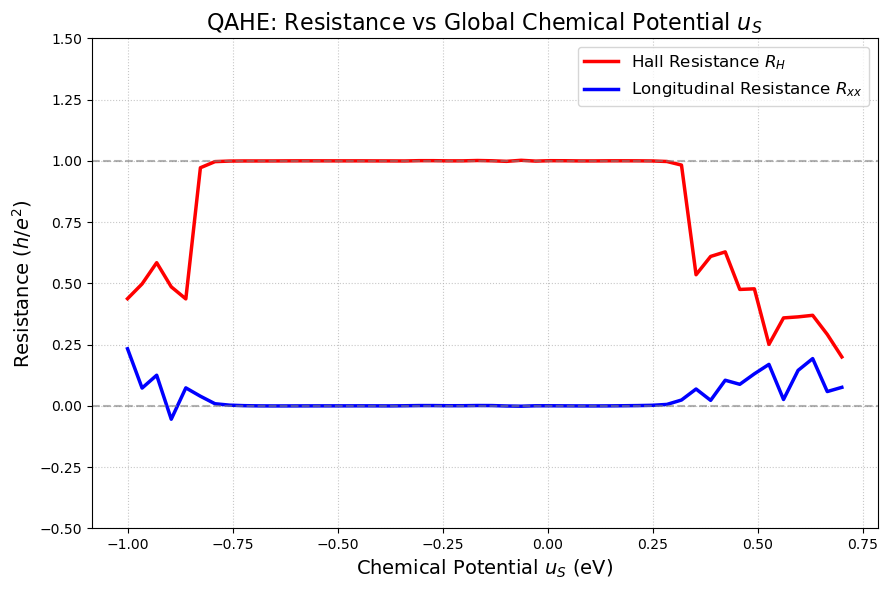

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================================================================
# 设定扫描参数
# =========================================================================
E_val = 0.25     # 固定的全局费米能级 (稍微偏离 0，模拟真实的费米面)
Ex = 0            
uS_array = np.linspace(-1, 0.7, 50)  # 全局化学势扫描范围

R_H_list = []
R_xx_list = []

print(f"开始计算：同步扫描中心区与探针引线的全局化学势 u_S (E={E_val}) ...")

for uS_val in tqdm(uS_array, desc="uS 扫描进度"):
    try:
        # =========================================================================
        # 1. 更新中心区域的 H_q_list
        # =========================================================================
        uS_set = []
        for i in range(xshumu):
            uS_set.append(uS_val - Ex * 1 * (i - xshumu/2))
        uS_set_base = np.array(uS_set)

        H_q_list = []
        for i in range(yshumu):
            H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
            H_q_list.append(H_q_i)

        # =========================================================================
        # 2. 核心修正：同步更新四根电压探针的在位能！
        # 确保探针与中心区是同一种材料的无缝延伸，不产生界面势垒
        # =========================================================================
        mu_probe_set_1 = np.full(yshumu_1, uS_val)
        mu_probe_set_2 = np.full(yshumu_2, uS_val)
        mu_probe_set_3 = np.full(yshumu_3, uS_val)
        mu_probe_set_4 = np.full(yshumu_4, uS_val)

        H_y1_dyn = H_onstie_lead_y(m, B, a, mu_probe_set_1, yshumu_1, Nd, A, Bz, top_x_edge)
        H_y2_dyn = H_onstie_lead_y(m, B, a, mu_probe_set_2, yshumu_2, Nd, A, Bz, top_x_edge)
        H_y3_dyn = H_onstie_lead_y(m, B, a, mu_probe_set_3, yshumu_3, Nd, A, Bz, bottom_x_edge)
        H_y4_dyn = H_onstie_lead_y(m, B, a, mu_probe_set_4, yshumu_4, Nd, A, Bz, bottom_x_edge)

        # =========================================================================
        # 3. 调用格林函数主程序 
        # (L, R 是普通金属，化学势保持之前设定的 mu=1 不变)
        # =========================================================================
        G_DD_r, Sigma_L, Sigma_R, Sigma_y1, Sigma_y2, Sigma_y3, Sigma_y4 = Gr_DD(
            H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, 
            H_y1_dyn, T_21_y1,
            H_y2_dyn, T_21_y2, 
            H_y3_dyn, T_21_y3,
            H_y4_dyn, T_21_y4, 
            yshumu, E=E_val, eta=1e-6
        )

        # =========================================================================
        # 4. Landauer-Büttiker 输运求解
        # =========================================================================
        N_total = G_DD_r.shape[0]
        d_slice = Sigma_L.shape[0]
        
        Sigma_L_global = np.zeros((N_total, N_total), dtype=complex)
        Sigma_R_global = np.zeros((N_total, N_total), dtype=complex)
        Sigma_L_global[:d_slice, :d_slice] = Sigma_L
        Sigma_R_global[-d_slice:, -d_slice:] = Sigma_R
        
        G_DD_a = G_DD_r.conj().T
        
        Gammas = [
            1j * (Sigma_L_global - Sigma_L_global.conj().T),
            1j * (Sigma_y1 - Sigma_y1.conj().T),
            1j * (Sigma_y2 - Sigma_y2.conj().T),
            1j * (Sigma_R_global - Sigma_R_global.conj().T),
            1j * (Sigma_y4 - Sigma_y4.conj().T),
            1j * (Sigma_y3 - Sigma_y3.conj().T)
        ]

        num_leads = 6
        T = np.zeros((num_leads, num_leads))
        for i in range(num_leads):
            for j in range(num_leads):
                if i != j:
                    T[i, j] = np.trace(Gammas[i] @ G_DD_r @ Gammas[j] @ G_DD_a).real
        
        G_mat = np.zeros((num_leads, num_leads))
        for i in range(num_leads):
            for j in range(num_leads):
                if i != j:
                    G_mat[i, j] = -T[i, j]
            G_mat[i, i] = np.sum(T[:, i]) - T[i, i]
            
        V_L, V_R = 1e-6, 0.0
        
        probe_indices = [1, 2, 4, 5]
        G_sub = G_mat[np.ix_(probe_indices, probe_indices)]
        I_sub = -(G_mat[probe_indices, 0] * V_L + G_mat[probe_indices, 3] * V_R)
        
        V_probes = np.linalg.solve(G_sub, I_sub)
        V_y1, V_y2, V_y4, V_y3 = V_probes
        
        V_all = [V_L, V_y1, V_y2, V_R, V_y4, V_y3]
        J1 = sum(G_mat[0, j] * V_all[j] for j in range(num_leads))
        
        if abs(J1) > 1e-15:
            R_H = (V_y1 - V_y3) / J1
            R_xx = (V_y1 - V_y2) / J1
        else:
            R_H = 0.0
            R_xx = 0.0
            
        R_H_list.append(R_H.real)
        R_xx_list.append(R_xx.real)
        
    except Exception as e:
        print(f"\n[跳过] uS = {uS_val:.2f} 处出现错误: {e}")
        R_H_list.append(np.nan)
        R_xx_list.append(np.nan)

print("扫描完毕！正在绘制图像...")

# =========================================================================
# 5. 绘制完美平台图像
# =========================================================================
plt.figure(figsize=(9, 6))

plt.plot(uS_array, R_H_list, 'r-', linewidth=2.5, label=r'Hall Resistance $R_H$')
plt.plot(uS_array, R_xx_list, 'b-', linewidth=2.5, label=r'Longitudinal Resistance $R_{xx}$')

plt.axhline(1.0, color='gray', linestyle='--', alpha=0.6)
plt.axhline(0.0, color='gray', linestyle='--', alpha=0.6)

plt.title('QAHE: Resistance vs Global Chemical Potential $u_S$', fontsize=16)
plt.xlabel(r'Chemical Potential $u_S$ (eV)', fontsize=14)
plt.ylabel(r'Resistance ($h/e^2$)', fontsize=14)

plt.ylim(-0.5, 1.5)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()